# NPS Agent with LangGraph + MLflow Tracing

Automatic tracing with `mlflow.langchain.autolog()` for a ReAct agent equipped with NPS API tools in LangGraph.

**Prerequisites:**
- NPS MCP server running on `localhost:3005` (see `nps_mcp_server.py` in this folder)
- `OPENAI_API_KEY` set in `.env` file in the parent directory (`agents_tracing-eval_mlflow/.env`)

## Configuration

Load environment variables and configure MLflow tracing.

In [1]:
import os
from dotenv import load_dotenv

# Load environment variables from parent directory .env file
load_dotenv(dotenv_path="../.env")

# Configuration
NPS_MCP_URL = "http://localhost:3005/sse"
OPENAI_MODEL = "gpt-4o"

# TODO : This example works with llamastack chat-completions but 
# throws pydantic related issues with llamastack Responses

## MLflow Setup

Configure MLflow tracking and enable LangChain auto-tracing.

**Important:** Call `mlflow.langchain.autolog()` AFTER importing LangChain/LangGraph modules.

In [2]:
import mlflow

# Set up MLflow tracking URI (local SQLite database)
db_path = os.path.join(os.getcwd(), "mlflow.db")
mlflow.set_tracking_uri(f"sqlite:///{db_path}")

# Set experiment name
mlflow.set_experiment("langgraph-nps-agent")

print(f"MLflow tracking URI: sqlite:///{db_path}")
print(f"Experiment: langgraph-nps-agent")

/Users/rranabha/red_hat_repos/agents/examples/agents_tracing-eval_mlflow/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/02/24 18:28:05 INFO mlflow.tracking.fluent: Experiment with name 'langgraph-nps-agent' does not exist. Creating a new experiment.


MLflow tracking URI: sqlite:////Users/rranabha/red_hat_repos/agents/examples/agents_tracing-eval_mlflow/nps_agent/mlflow.db
Experiment: langgraph-nps-agent


In [3]:
# Import LangChain/LangGraph modules first
from langchain_openai import ChatOpenAI
from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.graph import START, StateGraph, MessagesState
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.messages import HumanMessage, SystemMessage
from IPython.display import Image, display

# Enable autolog AFTER imports
mlflow.langchain.autolog(run_tracer_inline=False)
print("MLflow LangChain autolog enabled")

MLflow LangChain autolog enabled


## Connect to MCP Server

Initialize the MCP client and fetch available tools from the NPS MCP server.

In [4]:
# Initialize MCP client
# https://python.langchain.com/docs/integrations/tools/mcp/
# Note: SSE transport is deprecated by MCP project. Prefer Streamable HTTP or stdio when available.
client = MultiServerMCPClient(
    {
        "nps": {
            "transport": "sse",
            "url": NPS_MCP_URL,
        }
    }
)

# Get tools from MCP server
tools = await client.get_tools()
print(f"Loaded {len(tools)} tools from MCP server:")
for tool in tools:
    print(f"  - {tool.name}: {tool.description[:60]}...")

Loaded 5 tools from MCP server:
  - search_parks: Search for national parks by state, park code, or query stri...
  - get_park_alerts: Get current alerts for a specific national park.

Args:
    ...
  - get_park_campgrounds: Get campground information for a specific national park.

Ar...
  - get_park_events: Get upcoming events for a specific national park.

Args:
   ...
  - get_visitor_centers: Get visitor center information for a specific national park....


## Build the LangGraph ReAct Agent

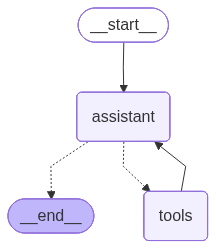

In [5]:
# Initialize LLM with tools
"""
NOTE : We aren't sending MCP server url but tool definitions only. Thus, setting `use_responses_api` to True
won't have any effect. If we had sent MCP server url (and flagged `use_responses_api=True`), tool calling orchestration would be handled by
providers like llamastack, openai e.t.c. 
This would mean the graph execution would be simply : < START_NODE, assistant_node, END_NODE >
And we wouldn't have spans from `tools` node of our graph below.
"""
llm = ChatOpenAI(
    model=OPENAI_MODEL,
    # use_responses_api=False
    )

# Uncomment and Edit accordingly If you are Using llamastack
# llm = ChatOpenAI(
#     model='openai/gpt-4o',
#     base_url="http://localhost:8321/v1/",
#     use_responses_api=False, ## Currently, ls server throws pydantic error if this is set to True
#     )

llm_with_tools = llm.bind_tools(tools)

# Define assistant node
def assistant(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build the graph
builder = StateGraph(MessagesState)

# Add nodes
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Add edges
builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

# Compile the graph
nps_agent = builder.compile()

# Visualize the graph
display(Image(nps_agent.get_graph(xray=True).draw_mermaid_png()))

SIDENOTE : Something similar is happening in [this](https://github.com/Nehanth/nps_agent/blob/main/agent.py) nps-agent-example that uses OpenAI's Agents SDK and `mlflow.openai.autolog()` for tracing.

Agents SDKs `agents.mcp.MCPServerSse` will only provide tool definition to llm-provider. Thus tool execution happens on host machine.

## Run the Agent

Invoke the agent with a query. Each graph invocation creates a trace.
Each Node (computation) in this graph creates a span. 
Inside our Node functions, we can further create [sub-spans](https://mlflow.org/docs/latest/genai/tracing/app-instrumentation/manual-tracing/#code-block) for a more customized span hierarchy.

In [6]:
# Run the agent
messages = [
    HumanMessage(content="Tell me about some parks in Rhode Island, and let me know if there are any upcoming events at them.")
]

response = await nps_agent.ainvoke({"messages": messages})

# Print the final response
print("\n--- Final Response ---")
print(response["messages"][-1].content)

2026/02/24 18:39:56 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: <Token var=<ContextVar name='current_context' default={} at 0x108cc1120> at 0x11d10e700> was created in a different Context
2026/02/24 18:39:56 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: <Token var=<ContextVar name='current_context' default={} at 0x108cc1120> at 0x11d2d76c0> was created in a different Context
2026/02/24 18:39:57 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: <Token var=<ContextVar name='current_context' default={} at 0x108cc1120> at 0x12040ed80> was created in a different Context
2026/02/24 18:39:57 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: <Token var=<ContextVar name='current_context' default={} at 0x108cc1120> at 0x11d2d7ac0> was created in a different Context
2026/02/24 18:39:58 WARNING mlflow.utils.autologging_utils: Encounte


--- Final Response ---
Here are some national parks in Rhode Island and their upcoming events:

### Blackstone River Valley National Historical Park
1. **[Women's History Month Open House: Leading the Change](https://www.nps.gov/blrv/index.htm)**
   - Celebrate Women's History Month at Old Slater Mill in Pawtucket, RI with guided tours, exhibits, and lectures on women's work and leadership.

2. **Revolutionary War Pension Files Transcription Event**
   - Participate in transcribing Revolutionary War pension files. Event to be held on March 11, 2026, at Linwood Mill, Whitinsville, MA. Bring a laptop.

3. **B.A.R.K. and P.U.R.R.K. Ranger Program**
   - Pet-friendly event at Roger Williams National Memorial. Learn about B.A.R.K & P.U.R.R.K Ranger programs, earn a collar charm, and take a walk on the Revolutionary Route National Historic Trail.

4. **Various Tours and Nature Programs**
   - Old Slater Mill Tours, Hikes, Fishing, and Nature Walks are available throughout the year, offering

![MLflow Trace](images/langgraph-nps-trace-mlflow.png)

## Tracking Conversations with Memory

Use `thread_id` to group related traces as one session.

**Reference:** https://mlflow.org/docs/latest/genai/tracing/integrations/listing/langgraph/#thread-id-tracking

In [11]:
from langgraph.checkpoint.memory import MemorySaver

# Add memory to the agent
memory = MemorySaver()
nps_agent_memory = builder.compile(checkpointer=memory)

In [12]:
# Specify a thread ID to group conversation traces
config = {"configurable": {"thread_id": "session-001"}}

In [13]:
# First message in the conversation
input_1 = [HumanMessage(content="Tell me about just one parks in Rhode Island.")]

output_1 = await nps_agent_memory.ainvoke({"messages": input_1}, config)

for m in output_1["messages"]:
    m.pretty_print()

2026/02/24 18:50:19 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: <Token var=<ContextVar name='current_context' default={} at 0x108cc1120> at 0x120662a80> was created in a different Context
2026/02/24 18:50:19 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: <Token var=<ContextVar name='current_context' default={} at 0x108cc1120> at 0x1204d4f00> was created in a different Context
2026/02/24 18:50:19 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: <Token var=<ContextVar name='current_context' default={} at 0x108cc1120> at 0x120517f80> was created in a different Context
2026/02/24 18:50:19 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: <Token var=<ContextVar name='current_context' default={} at 0x108cc1120> at 0x11c668740> was created in a different Context
2026/02/24 18:50:23 WARNING mlflow.utils.autologging_utils: Encounte

================================ Human Message =================================

Tell me about just one parks in Rhode Island.
================================== Ai Message ==================================
Tool Calls:
  search_parks (call_xfINhW6hoXWprJuqNudg17c2)
 Call ID: call_xfINhW6hoXWprJuqNudg17c2
  Args:
    state_code: RI
    limit: 1
================================= Tool Message =================================
Name: search_parks

[{'type': 'text', 'text': '{\n  "total": "4",\n  "parks": [\n    {\n      "name": "Blackstone River Valley National Historical Park",\n      "code": "blrv",\n      "description": "The Blackstone River powered America\'s entry into the Age of Industry. The success of Samuel Slater\'s cotton spinning mill in Pawtucket, RI touched off a chain reaction that changed how people worked and where they lived. Learn how this revolution transformed the landscape of the Blackstone Valley and the United States. The Visitor Center at Old Slater Mill is closed

In [14]:
# Follow-up message - the agent remembers the context from the same thread_id
input_2 = [HumanMessage(content="Could you just list coordinates ?")]

output_2 = await nps_agent_memory.ainvoke({"messages": input_2}, config)

for m in output_2["messages"]:
    m.pretty_print()

2026/02/24 18:53:50 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: <Token var=<ContextVar name='current_context' default={} at 0x108cc1120> at 0x120505580> was created in a different Context
2026/02/24 18:53:50 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: <Token var=<ContextVar name='current_context' default={} at 0x108cc1120> at 0x1204fef40> was created in a different Context
2026/02/24 18:53:50 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: <Token var=<ContextVar name='current_context' default={} at 0x108cc1120> at 0x1204edb40> was created in a different Context


================================ Human Message =================================

Tell me about just one parks in Rhode Island.
================================== Ai Message ==================================
Tool Calls:
  search_parks (call_xfINhW6hoXWprJuqNudg17c2)
 Call ID: call_xfINhW6hoXWprJuqNudg17c2
  Args:
    state_code: RI
    limit: 1
================================= Tool Message =================================
Name: search_parks

[{'type': 'text', 'text': '{\n  "total": "4",\n  "parks": [\n    {\n      "name": "Blackstone River Valley National Historical Park",\n      "code": "blrv",\n      "description": "The Blackstone River powered America\'s entry into the Age of Industry. The success of Samuel Slater\'s cotton spinning mill in Pawtucket, RI touched off a chain reaction that changed how people worked and where they lived. Learn how this revolution transformed the landscape of the Blackstone Valley and the United States. The Visitor Center at Old Slater Mill is closed

![MLflow Trace](images/grouping-traces.png)

![MLflow Trace](images/grouping-traces-2.png)

## Manually Group Traces with @mlflow.trace Decorator

Achieve similar behaviour as above using manual tracing.

**Reference:** https://mlflow.org/docs/latest/genai/tracing/track-users-sessions/

In [18]:
# Set a new experiment for manual tracing examples
mlflow.set_experiment("langgraph-manual-tracing")

# Rebuild a simple agent without memory for this example
react_graph = builder.compile()

def invoke_agent(input_messages):
    """Invoke the agent and print messages."""
    output = react_graph.invoke({"messages": input_messages})
    for m in output["messages"]:
        m.pretty_print()
    return output

@mlflow.trace
def graph_invocation(message, user_id, session_id):
    """Process a chat message with user and session tracking."""
    # Add user and session context to the current trace
    mlflow.update_current_trace(
        metadata={
            "mlflow.trace.user": user_id,
            "mlflow.trace.session": session_id,
        }
    )
    return invoke_agent(message)

2026/02/24 19:03:00 INFO mlflow.tracking.fluent: Experiment with name 'langgraph-manual-tracing' does not exist. Creating a new experiment.


In [19]:
# Run with user/session tracking
input_1 = [HumanMessage(content="Hi Agent! Tell me a joke.")]
output_1 = graph_invocation(input_1, "test-user", "test-session")

================================ Human Message =================================

Hi Agent! Tell me a joke.
================================== Ai Message ==================================

Why don't skeletons fight each other?

They don't have the guts!


In [20]:
# Continue the conversation (manually passing history)
input_2 = output_1["messages"] + [HumanMessage(content="Tell me another one about.")]
output_2 = graph_invocation(input_2, "test-user", "test-session")

================================ Human Message =================================

Hi Agent! Tell me a joke.
================================== Ai Message ==================================

Why don't skeletons fight each other?

They don't have the guts!
================================ Human Message =================================

Tell me another one about.
================================== Ai Message ==================================

Knock, knock.

Who’s there?

Lettuce.

Lettuce who?

Lettuce in, it's freezing out here!


![MLflow Trace](images/langgraph-nps-trace-mlflow.png)

## View Traces in MLflow UI

Start the MLflow UI to view your traces:

```bash
mlflow ui --port 5001 --backend-store-uri sqlite:///mlflow.db
```

Then open http://localhost:5001 in your browser.

### How to Navigate

1. **Select the Experiment** - Click on `langgraph-nps-agent` or `langgraph-manual-tracing` in the left sidebar
2. **Go to Traces tab** - Click the "Traces" tab to see all agent executions
3. **View Trace Details** - Click on any Trace ID to open the trace detail view
   - You'll see the span hierarchy showing the agent execution
   - Click on individual spans to see inputs/outputs for each step